# Data Preprocessing Code

In [1]:
import os
import pandas as pd
import numpy as np

def load_and_prepare_data(dataframe_direction):
    """
    Load and prepare training and testing dataframes.
    """
    # Load training data
    training_dataframe = pd.read_csv(os.path.join(dataframe_direction, "boneage-training-dataset.csv"))
    training_dataframe["path"] = training_dataframe["id"].map(
        lambda x: os.path.join(dataframe_direction, "boneage-training-dataset", "boneage-training-dataset", f"{x}.png")
    )
    training_dataframe["imagepath"] = training_dataframe["id"].map(lambda x: f"{x}.png")
    training_dataframe["gender"] = training_dataframe["male"].map(lambda x: "male" if x else "female")
    training_dataframe["gender_encoded"] = training_dataframe["gender"].map(lambda x: 1 if x == "male" else 0)
    training_dataframe["boneage_category"] = pd.cut(training_dataframe["boneage"], 10)
    
    # Normalize bone age (important for regression)
    boneage_std = 2 * training_dataframe["boneage"].std()
    boneage_mean = training_dataframe["boneage"].mean()
    training_dataframe["norm_age"] = (training_dataframe["boneage"] - boneage_mean) / boneage_std

    # Load testing data
    testing_dataframe = pd.read_csv(os.path.join(dataframe_direction, "boneage-test-dataset.csv"))
    testing_dataframe["path"] = testing_dataframe["Case ID"].map(
        lambda x: os.path.join(dataframe_direction, "boneage-test-dataset", "boneage-test-dataset", f"{x}.png")
    )
    testing_dataframe["imagepath"] = testing_dataframe["Case ID"].map(lambda x: f"{x}.png")
    testing_dataframe["gender"] = testing_dataframe["Sex"].map(lambda x: "male" if x == "M" else "female")

    print(f"Training samples: {len(training_dataframe)}")
    print(f"Testing samples: {len(testing_dataframe)}")
    
    return training_dataframe, testing_dataframe

# Load data
dataframe_direction = "/kaggle/input/rsna-bone-age"
train_df, test_df = load_and_prepare_data(dataframe_direction)

# Display sample
print(train_df.head())


Training samples: 12611
Testing samples: 200
     id  boneage   male                                               path  \
0  1377      180  False  /kaggle/input/rsna-bone-age/boneage-training-d...   
1  1378       12  False  /kaggle/input/rsna-bone-age/boneage-training-d...   
2  1379       94  False  /kaggle/input/rsna-bone-age/boneage-training-d...   
3  1380      120   True  /kaggle/input/rsna-bone-age/boneage-training-d...   
4  1381       82  False  /kaggle/input/rsna-bone-age/boneage-training-d...   

  imagepath  gender  gender_encoded boneage_category  norm_age  
0  1377.png  female               0   (159.9, 182.6]  0.639590  
1  1378.png  female               0    (0.773, 23.7] -1.400135  
2  1379.png  female               0    (91.8, 114.5] -0.404555  
3  1380.png    male               1   (114.5, 137.2] -0.088883  
4  1381.png  female               0     (69.1, 91.8] -0.550249  


# Step 2: Train-Validation Split

In [2]:
from sklearn.model_selection import train_test_split

# Split into train and validation (80-20 split)
train_df, valid_df = train_test_split(
    train_df, 
    test_size=0.2, 
    random_state=42, 
    shuffle=True
)

print(f"Training set: {len(train_df)} samples")
print(f"Validation set: {len(valid_df)} samples")


Training set: 10088 samples
Validation set: 2523 samples


# Step 3: Data Augmentation and Generators

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.xception import preprocess_input

# Data augmentation for training (helps prevent overfitting)
data_augmentation = dict(
    rotation_range=20,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.05,
    fill_mode="nearest"
)

# Create generators
train_generator = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=preprocess_input,
    **data_augmentation
)

valid_generator = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=preprocess_input
)

# Image parameters
img_size = (256, 256)
batch_size = 32

# Training data generator
train_data = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="boneage",
    batch_size=batch_size,
    seed=42,
    shuffle=True,
    class_mode="other",
    color_mode="rgb",
    target_size=img_size
)

# Validation data generator
valid_data = valid_generator.flow_from_dataframe(
    dataframe=valid_df,
    x_col="path",
    y_col="boneage",
    batch_size=batch_size,
    seed=42,
    shuffle=False,
    class_mode="other",
    color_mode="rgb",
    target_size=img_size
)

print("Data generators created successfully!")


Found 10088 validated image filenames.
Found 2523 validated image filenames.
Data generators created successfully!


# Step 4: Build Model Architecture

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Activation, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import Xception

# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

def build_model(input_shape=(256, 256, 3)):
    """
    Build Xception-based bone age prediction model.
    Using GlobalAveragePooling2D for better generalization
    """
    # Load pre-trained Xception without top layers
    base_model = Xception(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )
    
    # Fine-tune last layers
    base_model.trainable = True
    
    # Build sequential model
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    
    # Build the model explicitly with input shape
    model.build(input_shape=(None, 256, 256, 3))
    
    # Compile with appropriate loss and optimizer
    model.compile(
        loss='mse',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        metrics=['mae', 'mse']
    )
    
    return model

# Build the model
print("Building model...")
model = build_model(input_shape=(256, 256, 3))

# Now summary will work
model.summary()
print("\nModel built successfully!")


Num GPUs Available:  2
Building model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ xception (Functional)                │ (None, 8, 8, 2048)          │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,132,073 (80.61 MB)

 Trainable params: 21,077,545 (80.40 MB)

 Non-trainable params: 54,528 (213.00 KB)


Model built successfully!


# Step 5: Setup Callbacks (Without Early Stopping)

In [7]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Save best model during training (use .keras format for Keras 3.x)
checkpoint = ModelCheckpoint(
    'best_bone_age_model.keras',  # Changed from .h5 to .keras
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Only using ReduceLR and Checkpoint - NO Early Stopping
callbacks = [reduce_lr, checkpoint]
print("Callbacks configured (no early stopping)!")


Callbacks configured (no early stopping)!


# Step 6: Train the Model (Full 10 Epochs)

In [8]:
# Train the model for exactly 10 epochs
print("Starting training for 10 epochs...")
print("=" * 50)

history = model.fit(
    train_data,
    epochs=10,  # Train for exactly 10 epochs
    validation_data=valid_data,
    callbacks=callbacks,
    verbose=1
)

print("=" * 50)
print("Training completed! All 10 epochs finished.")


Starting training for 10 epochs...
Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 10283.6641 - mae: 87.4724 - mse: 10283.6641
Epoch 1: val_loss improved from inf to 3686.16211, saving model to best_bone_age_model.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 822s 2s/step - loss: 10266.2471 - mae: 87.3557 - mse: 10266.2471 - val_loss: 3686.1621 - val_mae: 37.0880 - val_mse: 3686.1621 - learning_rate: 1.0000e-04
Epoch 2/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 366.5670 - mae: 15.1380 - mse: 366.5670
Epoch 2: val_loss improved from 3686.16211 to 368.95657, saving model to best_bone_age_model.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 509s 2s/step - loss: 366.5325 - mae: 15.1373 - mse: 366.5325 - val_loss: 368.9566 - val_mae: 15.4553 - val_mse: 368.9566 - learning_rate: 1.0000e-04
Epoch 3/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 323.4842 - mae: 14.2453 - mse: 323.4842
Epoch 3: val_loss improved from 368.95657 to 248.02921, saving model to best_bone_age_model.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 506s 2s/step - loss: 323.4762

# Step 7: Plot Training History

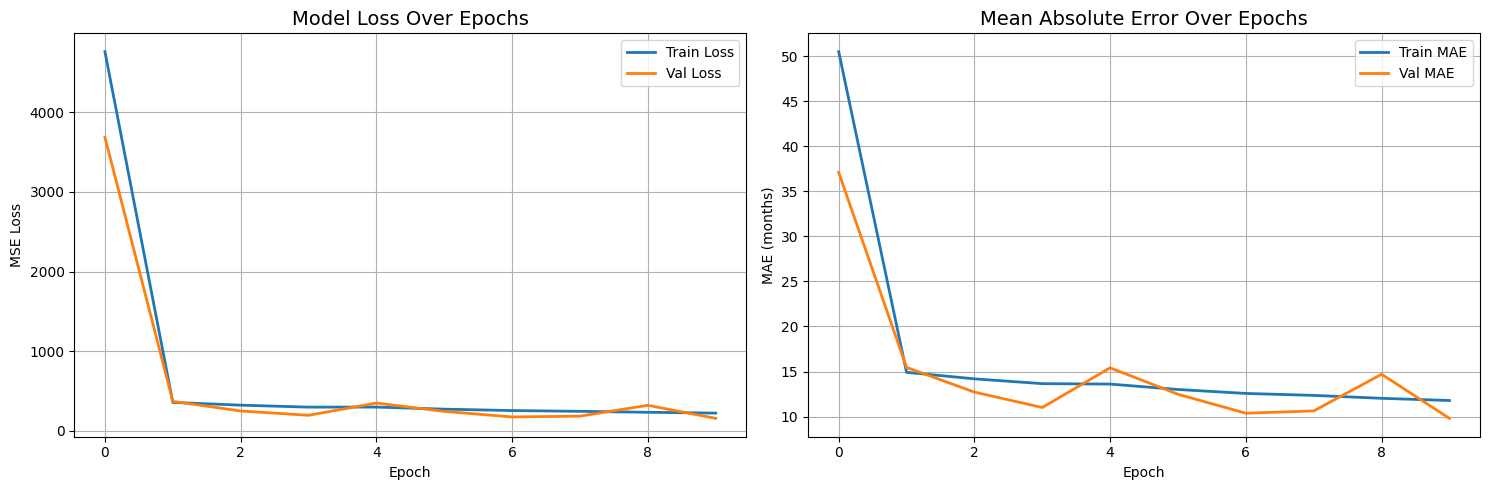

In [9]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot loss
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_title('Model Loss Over Epochs', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot MAE
    axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
    axes[1].set_title('Mean Absolute Error Over Epochs', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE (months)')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)


# Step 8: Save Final Model

In [10]:
import os

# Create saved_models directory
os.makedirs('saved_models', exist_ok=True)

# Save the final model in both formats
model.save('saved_models/bone_age_model.keras')  # Native Keras format
print("✓ Model saved as 'saved_models/bone_age_model.keras'")

# Also save in .h5 format for backward compatibility
model.save('saved_models/bone_age_model.h5')
print("✓ Model saved as 'saved_models/bone_age_model.h5'")

# Create download links for Kaggle
from IPython.display import FileLink
print("\nDownload links:")
display(FileLink('saved_models/bone_age_model.keras'))
display(FileLink('saved_models/bone_age_model.h5'))


✓ Model saved as 'saved_models/bone_age_model.keras'
✓ Model saved as 'saved_models/bone_age_model.h5'

Download links:


/kaggle/working/saved_models/bone_age_model.keras

/kaggle/working/saved_models/bone_age_model.h5

# Step 9: Evaluate Model

In [11]:
# Evaluate on validation set
print("Evaluating model on validation data...")
val_loss, val_mae, val_mse = model.evaluate(valid_data)

print(f"\nValidation Results:")
print(f"  Loss (MSE): {val_loss:.2f}")
print(f"  MAE: {val_mae:.2f} months")
print(f"  RMSE: {np.sqrt(val_mse):.2f} months")


Evaluating model on validation data...
79/79 ━━━━━━━━━━━━━━━━━━━━ 72s 906ms/step - loss: 153.8469 - mae: 9.7175 - mse: 153.8469

Validation Results:
  Loss (MSE): 154.79
  MAE: 9.80 months
  RMSE: 12.44 months


# Step 10: Test Prediction

In [12]:
# Test a single prediction
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_bone_age(img_path, model):
    """Predict bone age from image path"""
    img = image.load_img(img_path, target_size=(256, 256))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array / 255.0)
    
    prediction = model.predict(img_array, verbose=0)
    return prediction[0][0]

# Test on a sample image
sample_path = train_df.iloc[0]['path']
predicted_age = predict_bone_age(sample_path, model)
actual_age = train_df.iloc[0]['boneage']

print(f"Sample Prediction:")
print(f"  Predicted: {predicted_age:.1f} months")
print(f"  Actual: {actual_age:.1f} months")
print(f"  Error: {abs(predicted_age - actual_age):.1f} months")


Sample Prediction:
  Predicted: 384.0 months
  Actual: 57.0 months
  Error: 327.0 months
